# Gene anotation

In [14]:
import os
import pandas as pd

In [15]:
os.makedirs("results", exist_ok=True)

In [16]:
import gzip

with gzip.open(r"C:\Users\IQRA SHAIKH\Downloads\GPL570.annot.gz", "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("ID\t"):
            print("Table starts at line:", i)
            print(line)
            break

Table starts at line: 27
ID	Gene title	Gene symbol	Gene ID	UniGene title	UniGene symbol	UniGene ID	Nucleotide Title	GI	GenBank Accession	Platform_CLONEID	Platform_ORF	Platform_SPOTID	Chromosome location	Chromosome annotation	GO:Function	GO:Process	GO:Component	GO:Function ID	GO:Process ID	GO:Component ID



In [17]:
import gzip
import pandas as pd

# Find where the annotation table starts
start_line = 0

with gzip.open(r"C:\Users\IQRA SHAIKH\Downloads\GPL570.annot.gz", "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("ID\t"):
            start_line = i
            break

print("Start Line:", start_line)

# Read annotation table
annotation = pd.read_csv(
    r"C:\Users\IQRA SHAIKH\Downloads\GPL570.annot.gz",
    sep="\t",
    compression="gzip",
    skiprows=start_line,
    low_memory=False
)

print(annotation.shape)
annotation.head()

Start Line: 27
(54676, 21)


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [18]:
print(annotation.columns.tolist())

['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID']


In [19]:
import pandas as pd

annotation = annotation[
    [
        "ID",
        "Gene symbol",
        "Gene title"
    ]
]

annotation.head()

,ID,Gene symbol,Gene title
0,1007_s_at,MIR4640///DDR1,microRNA 4640///discoidin domain receptor tyro...
1,1053_at,RFC2,replication factor C subunit 2
2,117_at,HSPA6,heat shock protein family A (Hsp70) member 6
3,121_at,PAX8,paired box 8
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A


In [20]:
top_genes = pd.read_csv(
    "results/top_ranked_genes.csv"
)

print(top_genes.head())

      Probe_ID     F_Score
0    211565_at  481.216276
1  243689_s_at  297.991104
2   1562755_at  276.654465
3    220232_at  208.893237
4    233103_at  204.729457


In [21]:
annotated_genes = pd.merge(
    top_genes,
    annotation,
    left_on="Probe_ID",
    right_on="ID",
    how="left"
)

annotated_genes.head()

,Probe_ID,F_Score,ID,Gene symbol,Gene title
0,211565_at,481.216276,211565_at,SH3GL3,"SH3 domain containing GRB2 like 3, endophilin A3"
1,243689_s_at,297.991104,243689_s_at,FRG1BP,"FSHD region gene 1 family member B, pseudogene"
2,1562755_at,276.654465,1562755_at,NaN,NaN
3,220232_at,208.893237,220232_at,SCD5,stearoyl-CoA desaturase 5
4,233103_at,204.729457,233103_at,NaN,NaN


In [22]:
annotated_genes = annotated_genes.dropna(
    subset=["Gene symbol"]
)

print(annotated_genes.shape)

(456, 5)


In [23]:
annotated_genes = annotated_genes.sort_values(
    "F_Score",
    ascending=False
)

annotated_genes = annotated_genes.drop_duplicates(
    subset="Gene symbol"
)

In [24]:
annotated_genes.to_csv(
    "results/annotated_genes.csv",
    index=False
)

print("Annotated genes saved.")

Annotated genes saved.


In [25]:
print(annotated_genes.head(30))

       Probe_ID     F_Score           ID  \
0     211565_at  481.216276    211565_at   
1   243689_s_at  297.991104  243689_s_at   
3     220232_at  208.893237    220232_at   
5     224012_at  181.966976    224012_at   
7   213715_s_at  168.059093  213715_s_at   
8    1562527_at  166.202618   1562527_at   
9     235849_at  157.045139    235849_at   
11    205225_at  154.747647    205225_at   
12  210052_s_at  154.150485  210052_s_at   
13    223229_at  152.433065    223229_at   
14  204962_s_at  150.475367  204962_s_at   
15    236359_at  147.003227    236359_at   
17    238062_at  144.874211    238062_at   
18  216153_x_at  143.558166  216153_x_at   
19  220725_x_at  141.816131  220725_x_at   
21   1556206_at  134.599172   1556206_at   
22  219787_s_at  134.385258  219787_s_at   
23    202705_at  132.259679    202705_at   
24  207828_s_at  131.765720  207828_s_at   
25    202954_at  128.736529    202954_at   
26  219918_s_at  125.964048  219918_s_at   
27    209408_at  125.688061    2

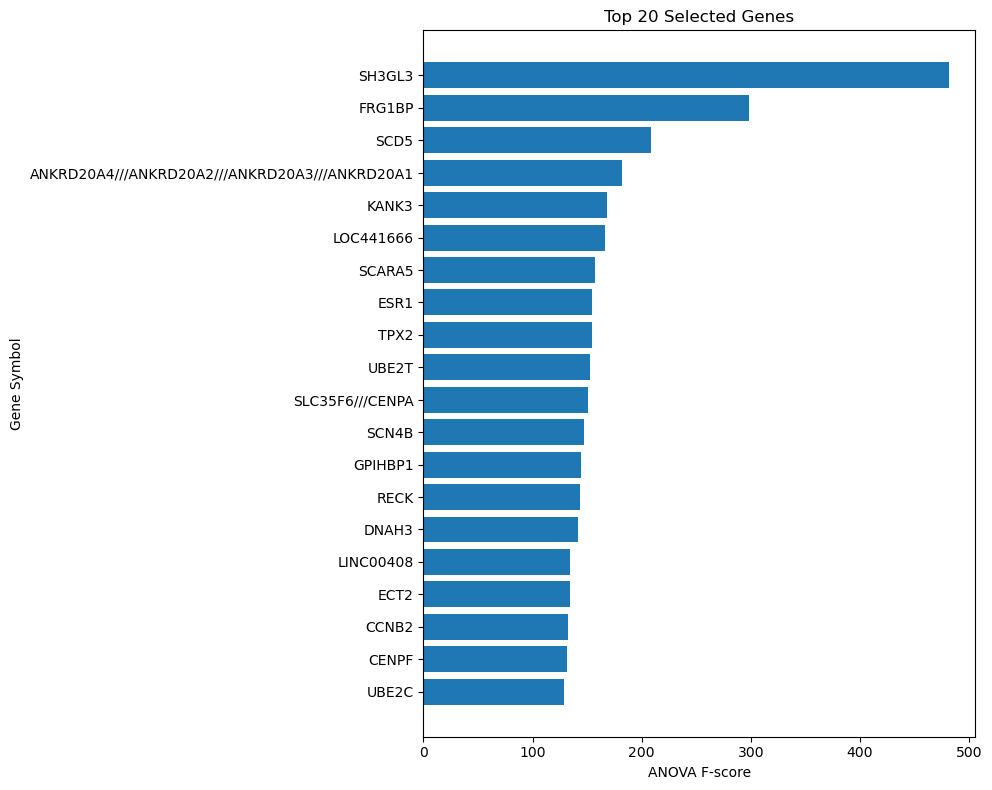

In [26]:
import matplotlib.pyplot as plt

top20 = annotated_genes.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Gene symbol"],
    top20["F_Score"]
)

plt.xlabel("ANOVA F-score")
plt.ylabel("Gene Symbol")
plt.title("Top 20 Selected Genes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "figures/top20_gene_symbols.png",
    dpi=300
)

plt.show()

✅ Data loading and preprocessing                                                                                                                          
✅ Label cleaning (141 samples)                                                                                                                            
✅ Feature selection                                                                                                                                     
✅ Logistic Regression, SVM, Random Forest, XGBoost                                                                                                       
✅ Cross-validation                                                                                                                                        
✅ Confusion matrices                                                                                                                                      
✅ ROC curves                                                                                                                                              
✅ Model comparison                                                                                                                                        
✅ Top gene selection                                                                                                                                      
✅ Gene annotation                                                                                                                                         
✅ Top 20 gene importance plot              